# **Tugas Besar IF3211 Komputasi Domain Spesifik: NutriAge**

NutriAge adalah aplikasi simulasi berbasis web yang mensimulasikan kebutuhan nutrisi makromolekul (karbohidrat, lipid, dan protein) berdasarkan usia dan jenis kelamin. Dikembangkan sebagai alat edukasi komputasional untuk mendukung pemahaman tentang Healthy Aging — proses menua secara sehat dengan asupan nutrisi yang tepat di setiap tahapan kehidupan.

## **Anggota Tim:**
*   18223011 Samuel Chris Michael Bagasta S
*   18223017 Carlen Asadel Axelle
*   18223054 Allodya Qonita Arofa
*   18223097 Audy Alicia Renatha Tirayoh

# Setup & Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json
import warnings

warnings.filterwarnings('ignore')

# visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Numpy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0


#Load Dataset (CSV from Drive)

In [ ]:
DRIVE_PATH = "https://drive.google.com/uc?export=download&id=1cmIW3NJ7LjuHmQhxuxVSHJHd3oJ7oXLJ" # Updated with direct download link

try:
    df_raw = pd.read_csv(DRIVE_PATH)
    print(f"✅ Dataset loaded successfully!")
    print(f"Shape: {df_raw.shape}")
    print(f"\nFirst few rows:")
    print(df_raw.head(10))
    print(f"\nColumn names:")
    print(df_raw.columns.tolist())
    print(f"\nData types:")
    print(df_raw.dtypes)

except FileNotFoundError:
    print(f"❌ File not found at: {DRIVE_PATH}")
    print("Please update DRIVE_PATH dengan path CSV mu yang bener")

except Exception as e:
    print(f"❌ Error loading file: {e}")

# Display dataset info
print(f"\n" + "="*50)
print("DATASET INFO")
print("="*50)
print(df_raw.info())
print(f"\n" + "="*50)
print("DATASET SUMMARY STATISTICS")
print("="*50)
print(df_raw.describe())

✅ Dataset loaded successfully!
Shape: (103, 8)

First few rows:
           age_group  min_age  max_age  gender  carbohydrate_g  lipid_g  \
0   Bayi (0-6 bulan)      0.0      0.5     All              60     30.0   
1   Bayi (0-6 bulan)      0.0      0.5     All              60     30.0   
2  Bayi (6-12 bulan)      0.5      1.0     All              95     30.0   
3  Bayi (6-12 bulan)      0.5      1.0     all              95     30.0   
4   Bayi (1-2 tahun)      1.0      2.0     All             100     30.0   
5   Bayi (1-2 tahun)      1.0      2.0    Male             102      NaN   
6   Anak (2-3 tahun)      2.0      3.0     All             115     30.0   
7   Anak (2-3 tahun)      2.0      3.0  female             115     30.0   
8   Anak (3-5 tahun)      3.0      5.0     All             130     35.0   
9   Anak (3-5 tahun)      3.0      5.0     All             130     35.0   

   protein_g                    notes  
0        9.1            Breastfeeding  
1        9.1            Breast

#Preprocessing & Cleaning

In [ ]:
df = df_raw.copy()

# MISSING VALUES
print("\n MISSING VALUES CHECK")
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percent': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

if len(missing_df) > 0:
    print("Missing values found:")
    print(missing_df)
    # Untuk age group, drop jika < 5% data
    for col in missing_df['Column']:
        if missing_df[missing_df['Column'] == col]['Missing_Percent'].values[0] < 5:
            if df[col].dtype == 'object':
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col].fillna(df[col].mean(), inplace=True)
            print(f"Filled {col} dengan mean/mode")
        else:
            print(f"{col} has >5% missing - pertimbangkan untuk di-drop atau di-handle manual")
else:
    print("No missing values found!")

# 2. DUPLICATE CHECK
print("\nDUPLICATE ROWS CHECK")
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ Removed {duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicates found!")

# 3. DATA TYPE VALIDATION
print("\nDATA TYPE VALIDATION")
expected_types = {
    'age_group': 'object',
    'min_age': 'int',
    'max_age': 'int',
    'gender': 'object',
}
# Untuk kolom nutrisi (karbohidrat, lipid, protein)
nutrient_cols = [col for col in df.columns if any(x in col.lower() for x in
                 ['requirement', 'carbohydrate', 'lipid', 'protein', 'fat', 'carb', '_g'])]

print(f"Nutrient columns detected: {nutrient_cols}")

for col in nutrient_cols:
    try:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"{col} converted to numeric")
    except:
        print(f"{col} could not be converted to numeric")

# 4. OUTLIER DETECTION (Z-score)
print("\nOUTLIER DETECTION")
outliers_found = False
for col in nutrient_cols:
    try:
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        outlier_mask = z_scores > 3  # 3 std deviations

        if outlier_mask.sum() > 0:
            print(f"{col}: Found {outlier_mask.sum()} potential outliers (Z-score > 3)")
            print(f"Values: {df[col][df[col].index.isin(df[z_scores > 3].index)].values}")
            outliers_found = True
        else:
            print(f"{col}: No significant outliers")
    except:
        print(f"{col}: Could not analyze (non-numeric or too few values)")

if not outliers_found:
    print("\nNo significant outliers detected!")

# 5. VALUE RANGE VALIDATION
print("\nVALUE RANGE VALIDATION")

if 'min_age' in df.columns and 'max_age' in df.columns:
    invalid_ages = df[(df['min_age'] < 0) | (df['max_age'] > 120) | (df['min_age'] > df['max_age'])]
    if len(invalid_ages) > 0:
        print(f"   ⚠️ Found {len(invalid_ages)} rows with invalid age ranges")
        print(invalid_ages)
    else:
        print("   ✓ Age ranges are valid")

for col in nutrient_cols:
    negative_vals = df[df[col] < 0]
    if len(negative_vals) > 0:
        print(f"   ⚠️ {col} contains {len(negative_vals)} negative values - setting to 0")
        df[col] = df[col].clip(lower=0)
    else:
        print(f"   ✓ {col}: All positive values")

# 6. NORMALIZE COLUMN NAMES
print("\nNORMALIZE COLUMN NAMES")

# Convert to lowercase, replace spaces with underscore
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
print(f"Column names normalized")
print(f"New columns: {df.columns.tolist()}")

# 7. FINAL DATASET INFO
print("\n")
print("PREPROCESSING DONE!!!!!!")
print(f"Final shape: {df.shape}")
print(f"Total rows: {len(df)} | Total columns: {len(df.columns)}")
print(f"\nFinal columns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\n{df.head(10)}")


 MISSING VALUES CHECK
Missing values found:
    Column  Missing_Count  Missing_Percent
7    notes             49        47.572816
5  lipid_g              5         4.854369
notes has >5% missing - pertimbangkan untuk di-drop atau di-handle manual
Filled lipid_g dengan mean/mode

DUPLICATE ROWS CHECK
Total duplicate rows: 8
✓ Removed 8 duplicate rows. New shape: (95, 8)

DATA TYPE VALIDATION
Nutrient columns detected: ['age_group', 'carbohydrate_g', 'lipid_g', 'protein_g']
age_group converted to numeric
carbohydrate_g converted to numeric
lipid_g converted to numeric
protein_g converted to numeric

OUTLIER DETECTION
age_group: No significant outliers
carbohydrate_g: Found 1 potential outliers (Z-score > 3)
Values: [999]
lipid_g: No significant outliers
protein_g: No significant outliers

VALUE RANGE VALIDATION
   ✓ Age ranges are valid
   ✓ age_group: All positive values
   ⚠️ carbohydrate_g contains 1 negative values - setting to 0
   ✓ lipid_g: All positive values
   ✓ protein_g: All

##Carbohydrate Module

DATA KARBOHIDRAT - Preview
Total baris data karbohidrat: 95
  -> Dengan gender spesifik : 78
  -> Dengan gender 'All'    : 17
  -> Nilai invalid/outlier  : 2 baris

 min_age  max_age gender  carbohydrate_g  carbohydrate_g_clean
     0.0      0.5    all              60                  60.0
     0.0      0.5    all              60                  60.0
     0.0      0.5    all              60                  60.0
     0.5      1.0    all              95                  95.0
     0.5      1.0    all              95                  95.0
     0.5      1.0    all              95                  95.0
     1.0      2.0    all             100                 100.0
     1.0      2.0    all             100                 100.0
     1.0      2.0    all              98                  98.0
     1.0      2.0   male             102                 102.0
     2.0      3.0    all             115                 115.0
     2.0      3.0    all             115                 115.0
     2.0      3.

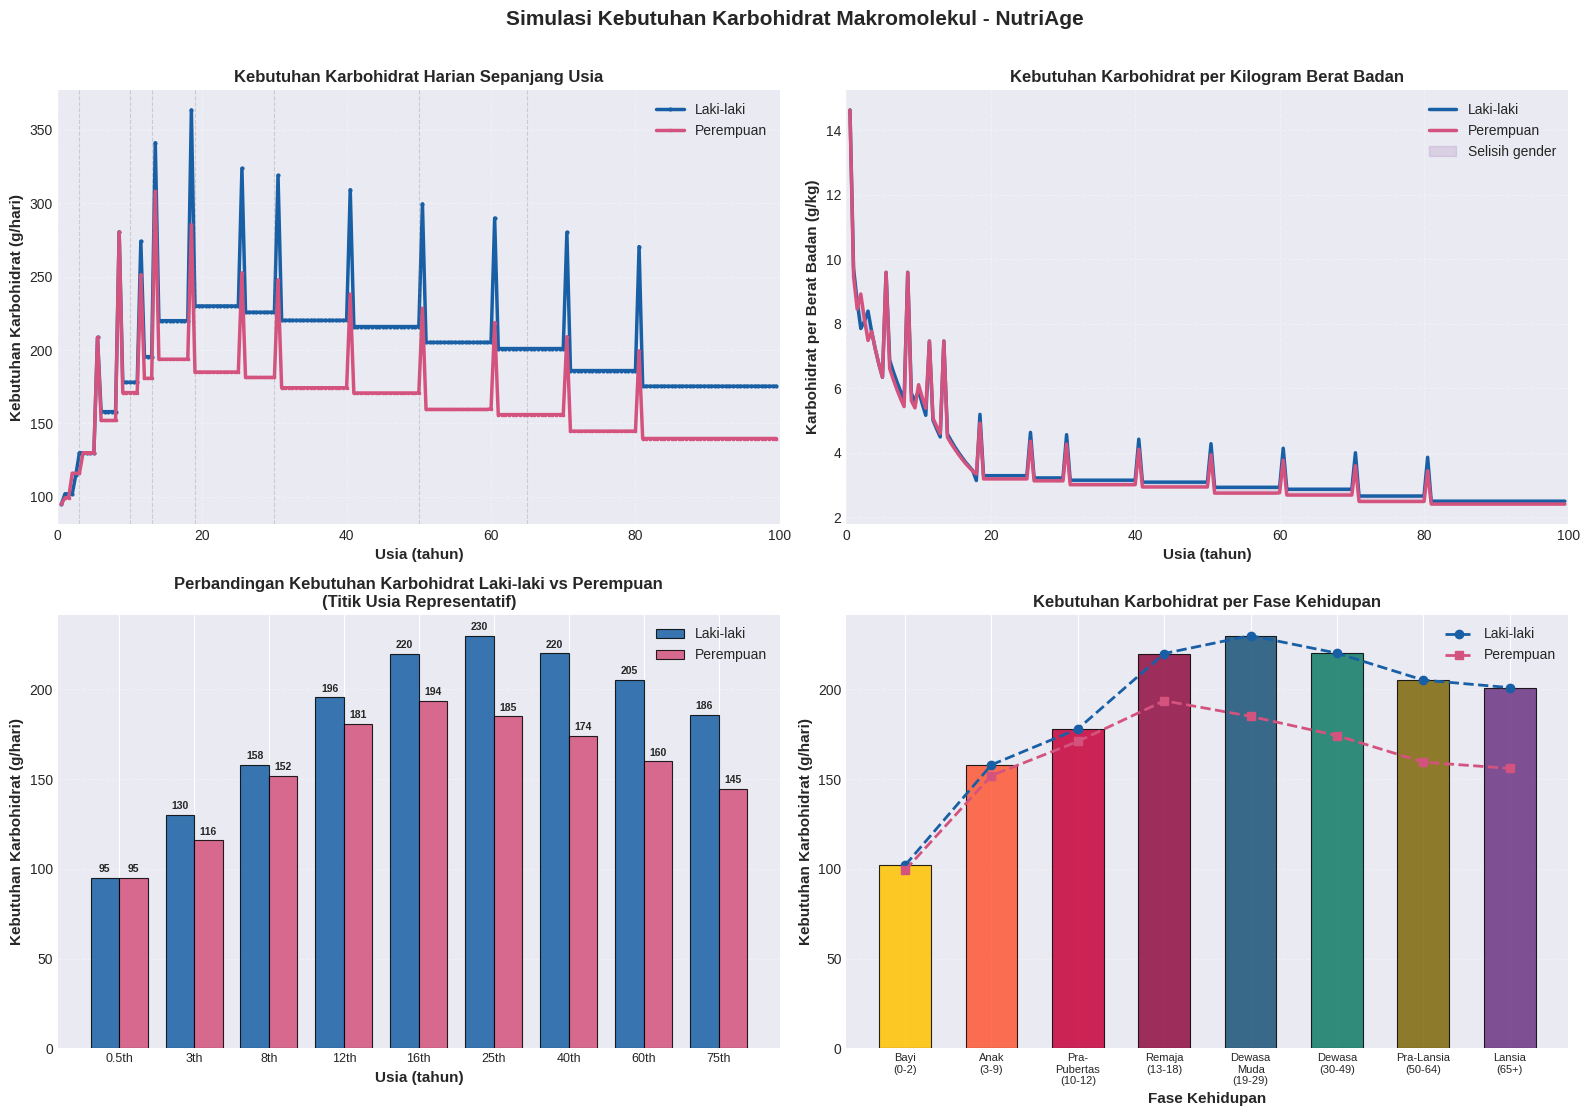

Grafik disimpan sebagai carbohydrate_simulation_analysis.png


In [ ]:
# CARBOHYDRATE MODULE - NutriAge

# BAGIAN 1: PERSIAPAN DATA KARBOHIDRAT

required_carb_cols = ['min_age', 'max_age', 'gender', 'carbohydrate_g']
missing_carb_cols = [col for col in required_carb_cols if col not in df.columns]
if missing_carb_cols:
    raise KeyError(f'Kolom wajib untuk carbohydrate module tidak ditemukan: {missing_carb_cols}')

carb_df = df[required_carb_cols].copy()
carb_df['gender'] = carb_df['gender'].astype(str).str.strip().str.lower()
carb_df['carbohydrate_g'] = pd.to_numeric(carb_df['carbohydrate_g'], errors='coerce')
carb_df['carbohydrate_g_clean'] = carb_df['carbohydrate_g'].astype(float)

# Dataset mengandung nilai ekstrem/hasil clipping; biarkan sebagai NaN agar tidak merusak rata-rata lookup.
carb_invalid_mask = (
    carb_df['carbohydrate_g_clean'].isna() |
    (carb_df['carbohydrate_g_clean'] < 20) |
    (carb_df['carbohydrate_g_clean'] > 450)
)
carb_df.loc[carb_invalid_mask, 'carbohydrate_g_clean'] = np.nan

carb_all = carb_df[carb_df['gender'] == 'all'].copy()
carb_gendered = carb_df[carb_df['gender'].isin(['male', 'female'])].copy()

print('DATA KARBOHIDRAT - Preview')
print('='*60)
print(f'Total baris data karbohidrat: {len(carb_df)}')
print(f'  -> Dengan gender spesifik : {len(carb_gendered)}')
print(f"  -> Dengan gender 'All'    : {len(carb_all)}")
print(f'  -> Nilai invalid/outlier  : {carb_invalid_mask.sum()} baris')
print()
print(carb_df.sort_values(['min_age', 'gender']).to_string(index=False))


# BAGIAN 2: FUNGSI UTILITAS - KLASIFIKASI KELOMPOK USIA

def get_carbohydrate_age_group(age):
    """Klasifikasikan usia ke kelompok nutrisi dan fase metabolisme karbohidrat."""
    if age < 0 or age > 120:
        return {'status': 'error', 'message': f'Usia tidak valid: {age}. Masukkan nilai 0-120.'}

    if age < 0.5:
        group, phase, meta_phase = 'Bayi (0-6 bulan)', 'Neonatal', 'Pasokan Glukosa Cepat'
    elif age < 1:
        group, phase, meta_phase = 'Bayi (6-12 bulan)', 'MPASI Awal', 'Adaptasi Karbohidrat Kompleks'
    elif age < 3:
        group, phase, meta_phase = 'Bayi (1-2 tahun)', 'Toddler', 'Pertumbuhan Otak Aktif'
    elif age < 6:
        group, phase, meta_phase = 'Anak (3-5 tahun)', 'Prasekolah', 'Energi Bermain dan Belajar'
    elif age < 10:
        group, phase, meta_phase = 'Anak (6-9 tahun)', 'Sekolah Dasar', 'Energi Pertumbuhan Stabil'
    elif age < 13:
        group, phase, meta_phase = 'Anak (10-12 tahun)', 'Prapubertas', 'Cadangan Energi Pra-Pubertas'
    elif age < 16:
        group, phase, meta_phase = 'Remaja (13-15 tahun)', 'Pubertas Awal', 'Lonjakan Energi Pubertas'
    elif age < 19:
        group, phase, meta_phase = 'Remaja (16-18 tahun)', 'Pubertas Akhir', 'Pemulihan Glikogen Tinggi'
    elif age < 30:
        group, phase, meta_phase = 'Dewasa Muda (19-29 tahun)', 'Dewasa Muda', 'Keseimbangan Energi Produktif'
    elif age < 50:
        group, phase, meta_phase = 'Dewasa (30-49 tahun)', 'Dewasa Tengah', 'Kontrol Glikemik dan Energi'
    elif age < 65:
        group, phase, meta_phase = 'Pra-Lansia (50-64 tahun)', 'Pra-Lansia', 'Sensitivitas Insulin Menurun'
    else:
        group, phase, meta_phase = 'Lansia (65+ tahun)', 'Lansia', 'Karbohidrat Padat Gizi'

    return {
        'status': 'ok',
        'age_group': group,
        'biological_phase': phase,
        'metabolic_phase': meta_phase
    }


def _select_carb_age_rows(table, age):
    """Ambil baris referensi usia; bila usia tepat di batas bawah, prioritaskan interval baru."""
    matches = table[(table['min_age'] <= age) & (table['max_age'] >= age)]
    if matches.empty:
        return matches

    exact_start = matches[np.isclose(matches['min_age'], age)]
    if not exact_start.empty:
        return exact_start

    return matches


def _mean_clean_carbohydrate(rows):
    valid_values = rows['carbohydrate_g_clean'].dropna()
    if valid_values.empty:
        return None
    return float(valid_values.mean())


# BAGIAN 3: FUNGSI LOOKUP - KEBUTUHAN KARBOHIDRAT DARI DATASET

def lookup_carbohydrate_from_dataset(age, gender):
    """Cari kebutuhan karbohidrat gram/hari dari dataset berdasarkan usia dan gender."""
    gender_norm = gender.strip().lower()

    match_gendered = _select_carb_age_rows(carb_gendered[carb_gendered['gender'] == gender_norm], age)
    carb_g = _mean_clean_carbohydrate(match_gendered)
    if carb_g is not None:
        return carb_g, 'dataset referensi gender-spesifik'

    match_all = _select_carb_age_rows(carb_all, age)
    carb_g = _mean_clean_carbohydrate(match_all)
    if carb_g is not None:
        return carb_g, "dataset referensi gender 'all'"

    return None, 'estimasi energi'


# BAGIAN 4: ESTIMASI ENERGI UNTUK FALLBACK DAN KONTEKS

def estimate_body_weight_for_carb(age, gender):
    """Estimasi berat badan sederhana untuk konteks kebutuhan karbohidrat."""
    gender_lower = gender.strip().lower()

    if age < 1:
        return 3.5 + age * 6
    if age < 10:
        return 8 + age * 2.5
    if age < 18:
        return 30 + (age - 10) * 4.5 if gender_lower == 'male' else 28 + (age - 10) * 3.8
    return 70.0 if gender_lower == 'male' else 58.0


def get_carb_activity_factor(activity_level='moderate'):
    factors = {
        'sedentary': 1.2,
        'light': 1.375,
        'moderate': 1.55,
        'very_active': 1.725,
        'extra_active': 1.9
    }
    return factors.get(str(activity_level).lower(), 1.55)


def estimate_tdee_for_carb(age, gender, body_weight=None, activity_level='moderate'):
    """Estimasi TDEE sederhana untuk menghitung kontribusi energi karbohidrat."""
    bw = body_weight if body_weight is not None else estimate_body_weight_for_carb(age, gender)
    gender_lower = gender.strip().lower()

    if age < 1:
        bmr = 58 * bw
    elif age < 3:
        bmr = 55 * bw
    elif age < 10:
        bmr = 45 * bw
    elif age < 18:
        bmr = 35 * bw
    else:
        height = 175 if gender_lower == 'male' else 162
        sex_constant = 5 if gender_lower == 'male' else -161
        bmr = (10 * bw) + (6.25 * height) - (5 * age) + sex_constant

    return bmr * get_carb_activity_factor(activity_level)


def estimate_carbohydrate_by_energy(age, gender, body_weight=None, activity_level='moderate'):
    """Fallback: estimasi karbohidrat dari persentase energi harian."""
    tdee = estimate_tdee_for_carb(age, gender, body_weight, activity_level)
    if age < 1:
        carb_energy_ratio = 0.40
    elif age < 19:
        carb_energy_ratio = 0.55
    else:
        carb_energy_ratio = 0.50
    return (tdee * carb_energy_ratio) / 4


# BAGIAN 5: FUNGSI UTAMA - SIMULASI KEBUTUHAN KARBOHIDRAT

def simulate_carbohydrate_requirement(age, gender, body_weight=None, activity_level='moderate'):
    """Simulasikan kebutuhan karbohidrat harian berdasarkan usia, gender, dan konteks energi."""
    if age < 0 or age > 120:
        return {'status': 'error', 'message': f'Usia tidak valid: {age}. Masukkan nilai 0-120.'}

    if gender.strip().lower() not in ['male', 'female']:
        return {'status': 'error', 'message': f'Gender tidak valid: {gender}. Gunakan Male atau Female.'}

    if body_weight is not None and (body_weight < 2 or body_weight > 300):
        return {'status': 'error', 'message': f'Berat badan tidak valid: {body_weight} kg.'}

    age_info = get_carbohydrate_age_group(age)
    if age_info['status'] == 'error':
        return age_info

    bw = body_weight if body_weight is not None else estimate_body_weight_for_carb(age, gender)
    carb_g, data_source = lookup_carbohydrate_from_dataset(age, gender)

    if carb_g is None:
        carb_g = estimate_carbohydrate_by_energy(age, gender, bw, activity_level)
        data_source = 'estimated (persentase energi harian)'

    tdee = estimate_tdee_for_carb(age, gender, bw, activity_level)
    carb_kcal = carb_g * 4
    carb_energy_pct = (carb_kcal / tdee) * 100 if tdee > 0 else None
    carb_per_kg = carb_g / bw if bw > 0 else None

    recommendation = generate_carbohydrate_recommendation(age_info, gender, carb_g)
    bio_insight = get_carbohydrate_biological_insight(age_info['metabolic_phase'])

    return {
        'status': 'success',
        'age': age,
        'gender': gender.capitalize(),
        'age_group': age_info['age_group'],
        'biological_phase': age_info['biological_phase'],
        'metabolic_phase': age_info['metabolic_phase'],
        'body_weight_est': round(bw, 1),
        'activity_level': activity_level,
        'tdee_est': round(tdee, 1),
        'carbohydrate_g_per_day': round(carb_g, 1),
        'carbohydrate_kcal': round(carb_kcal, 1),
        'carbohydrate_energy_pct': round(carb_energy_pct, 1) if carb_energy_pct is not None else None,
        'carbohydrate_per_kg': round(carb_per_kg, 2) if carb_per_kg is not None else None,
        'data_source': data_source,
        'recommendation': recommendation,
        'bio_insight': bio_insight
    }


def generate_carbohydrate_recommendation(age_info, gender, carbohydrate_g):
    """Hasilkan teks rekomendasi konsumsi karbohidrat berdasarkan fase metabolisme."""
    phase = age_info['metabolic_phase']
    group = age_info['age_group']
    gender_cap = gender.capitalize()

    recs = {
        'Pasokan Glukosa Cepat': f'{group} membutuhkan sekitar {carbohydrate_g:.1f}g karbohidrat/hari. Sumber utama tetap ASI atau formula; hindari gula tambahan.',
        'Adaptasi Karbohidrat Kompleks': f'{group} membutuhkan {carbohydrate_g:.1f}g/hari. Perkenalkan MPASI kaya karbohidrat kompleks seperti bubur beras, kentang, dan buah lumat.',
        'Pertumbuhan Otak Aktif': f'{gender_cap} usia {group} memerlukan {carbohydrate_g:.1f}g/hari untuk mendukung energi otak dan aktivitas motorik.',
        'Energi Bermain dan Belajar': f'Kebutuhan {carbohydrate_g:.1f}g/hari sebaiknya dipenuhi dari nasi, roti gandum, umbi, buah, dan sayur agar energi lebih stabil.',
        'Energi Pertumbuhan Stabil': f'Karbohidrat {carbohydrate_g:.1f}g/hari membantu konsentrasi sekolah dan aktivitas fisik. Batasi minuman manis.',
        'Cadangan Energi Pra-Pubertas': f'Usia pra-pubertas membutuhkan {carbohydrate_g:.1f}g/hari sebagai cadangan energi sebelum lonjakan pertumbuhan.',
        'Lonjakan Energi Pubertas': f'Remaja membutuhkan sekitar {carbohydrate_g:.1f}g/hari. Pilih karbohidrat kompleks untuk mengisi glikogen dan mendukung pertumbuhan.',
        'Pemulihan Glikogen Tinggi': f'Kebutuhan {carbohydrate_g:.1f}g/hari penting untuk pemulihan glikogen, terutama bila aktif olahraga.',
        'Keseimbangan Energi Produktif': f'Dewasa muda membutuhkan {carbohydrate_g:.1f}g/hari. Targetkan 45-65% energi dari karbohidrat berkualitas dan tinggi serat.',
        'Kontrol Glikemik dan Energi': f'Kebutuhan {carbohydrate_g:.1f}g/hari perlu disebar merata antar waktu makan untuk menjaga kontrol glikemik.',
        'Sensitivitas Insulin Menurun': f'Pada pra-lansia, {carbohydrate_g:.1f}g/hari sebaiknya dominan dari sumber indeks glikemik rendah dan tinggi serat.',
        'Karbohidrat Padat Gizi': f'Lansia membutuhkan {carbohydrate_g:.1f}g/hari dari sumber padat gizi seperti oat, nasi merah, umbi, kacang, buah, dan sayur.'
    }
    return recs.get(phase, f'Konsumsi sekitar {carbohydrate_g:.1f}g karbohidrat per hari sesuai kebutuhan energi.')


def get_carbohydrate_biological_insight(metabolic_phase):
    """Kembalikan insight biologis singkat berdasarkan fase metabolisme karbohidrat."""
    insights = {
        'Pasokan Glukosa Cepat': 'Otak bayi memakai glukosa sangat intensif; laktosa dari ASI menjadi sumber karbohidrat utama.',
        'Adaptasi Karbohidrat Kompleks': 'Aktivitas amilase meningkat bertahap sehingga bayi mulai mampu mencerna pati dari MPASI.',
        'Pertumbuhan Otak Aktif': 'Karbohidrat memasok glukosa untuk perkembangan saraf dan aktivitas eksplorasi yang tinggi.',
        'Energi Bermain dan Belajar': 'Glikogen otot dan hati cepat dipakai saat anak aktif bermain; pola makan teratur membantu energi stabil.',
        'Energi Pertumbuhan Stabil': 'Glukosa mendukung konsentrasi dan aktivitas sekolah, sedangkan serat membantu kesehatan mikrobiota usus.',
        'Cadangan Energi Pra-Pubertas': 'Kebutuhan energi naik sebelum pubertas karena jaringan tubuh mulai bersiap untuk growth spurt.',
        'Lonjakan Energi Pubertas': 'Pubertas meningkatkan kebutuhan glikogen untuk pertumbuhan cepat dan aktivitas fisik.',
        'Pemulihan Glikogen Tinggi': 'Karbohidrat membantu resintesis glikogen setelah aktivitas dan mendukung performa belajar/olahraga.',
        'Keseimbangan Energi Produktif': 'Kualitas karbohidrat menentukan kestabilan energi kerja, mood, dan rasa kenyang.',
        'Kontrol Glikemik dan Energi': 'Distribusi karbohidrat dan serat memperlambat absorpsi glukosa sehingga respons insulin lebih stabil.',
        'Sensitivitas Insulin Menurun': 'Sensitivitas insulin cenderung menurun; karbohidrat kompleks membantu mengurangi lonjakan glukosa.',
        'Karbohidrat Padat Gizi': 'Pada lansia, karbohidrat tinggi serat membantu kesehatan pencernaan dan mengurangi risiko konstipasi.'
    }
    return insights.get(metabolic_phase, 'Karbohidrat adalah sumber energi utama untuk otak, otot, dan sistem saraf.')


# BAGIAN 6: PENGUJIAN FUNGSI SIMULASI

print('\nCARBOHYDRATE MODULE - Simulation Testing')
print('='*70)

carb_test_cases = [
    (0.3, 'Male', None, 'moderate'),
    (1, 'Female', None, 'moderate'),
    (5, 'Male', None, 'moderate'),
    (12, 'Female', None, 'moderate'),
    (16, 'Male', None, 'moderate'),
    (25, 'Female', 58, 'moderate'),
    (40, 'Male', 70, 'light'),
    (60, 'Female', 58, 'sedentary'),
    (75, 'Male', 70, 'sedentary'),
]

carb_results = []

for age, gender, weight, activity in carb_test_cases:
    result = simulate_carbohydrate_requirement(age, gender, weight, activity)
    carb_results.append(result)
    if result['status'] == 'success':
        carb_val = result['carbohydrate_g_per_day']
        kcal_val = result['carbohydrate_kcal']
        pct_val = result['carbohydrate_energy_pct']
        bw_val = result['body_weight_est']
        print(f'Usia {str(age):5s} | {gender:6s} | BB ~{bw_val:5.1f}kg | Karbohidrat: {carb_val:6.1f} g/hari | {kcal_val:6.0f} kcal')
        print(f"  Kontribusi energi : {pct_val}% dari estimasi TDEE")
        print(f"  Kelompok          : {result['age_group']}")
        print(f"  Fase metabolisme  : {result['metabolic_phase']}")
        print(f"  Sumber            : {result['data_source']}")
        print()


# BAGIAN 7: VISUALISASI KEBUTUHAN KARBOHIDRAT SEPANJANG USIA

ages_viz_carb = np.arange(0.5, 100, 0.5)

carb_male_viz = [simulate_carbohydrate_requirement(a, 'Male')['carbohydrate_g_per_day'] for a in ages_viz_carb]
carb_female_viz = [simulate_carbohydrate_requirement(a, 'Female')['carbohydrate_g_per_day'] for a in ages_viz_carb]
carb_per_kg_male_viz = [simulate_carbohydrate_requirement(a, 'Male')['carbohydrate_per_kg'] for a in ages_viz_carb]
carb_per_kg_female_viz = [simulate_carbohydrate_requirement(a, 'Female')['carbohydrate_per_kg'] for a in ages_viz_carb]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Simulasi Kebutuhan Karbohidrat Makromolekul - NutriAge', fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Kebutuhan karbohidrat vs usia
ax = axes[0, 0]
ax.plot(ages_viz_carb, carb_male_viz, linewidth=2.5, label='Laki-laki', color='#185FA5', marker='o', markersize=2)
ax.plot(ages_viz_carb, carb_female_viz, linewidth=2.5, label='Perempuan', color='#D4537E', marker='s', markersize=2)
for x_line in [3, 10, 13, 19, 30, 50, 65]:
    ax.axvline(x=x_line, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
ax.set_xlabel('Usia (tahun)', fontsize=11, fontweight='bold')
ax.set_ylabel('Kebutuhan Karbohidrat (g/hari)', fontsize=11, fontweight='bold')
ax.set_title('Kebutuhan Karbohidrat Harian Sepanjang Usia', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0, 100)

# Plot 2: Karbohidrat per kg berat badan
ax = axes[0, 1]
ax.plot(ages_viz_carb, carb_per_kg_male_viz, linewidth=2.5, label='Laki-laki', color='#185FA5')
ax.plot(ages_viz_carb, carb_per_kg_female_viz, linewidth=2.5, label='Perempuan', color='#D4537E')
ax.fill_between(ages_viz_carb, carb_per_kg_male_viz, carb_per_kg_female_viz, alpha=0.15, color='#7D3C98', label='Selisih gender')
ax.set_xlabel('Usia (tahun)', fontsize=11, fontweight='bold')
ax.set_ylabel('Karbohidrat per Berat Badan (g/kg)', fontsize=11, fontweight='bold')
ax.set_title('Kebutuhan Karbohidrat per Kilogram Berat Badan', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0, 100)

# Plot 3: Perbandingan gender pada usia representatif
ax = axes[1, 0]
rep_ages_carb = [0.5, 3, 8, 12, 16, 25, 40, 60, 75]
rep_male_carb = [simulate_carbohydrate_requirement(a, 'Male')['carbohydrate_g_per_day'] for a in rep_ages_carb]
rep_female_carb = [simulate_carbohydrate_requirement(a, 'Female')['carbohydrate_g_per_day'] for a in rep_ages_carb]
x_pos = np.arange(len(rep_ages_carb))
bar_w = 0.38
bars_m = ax.bar(x_pos - bar_w/2, rep_male_carb, bar_w, label='Laki-laki', color='#185FA5', alpha=0.85, edgecolor='black', linewidth=0.8)
bars_f = ax.bar(x_pos + bar_w/2, rep_female_carb, bar_w, label='Perempuan', color='#D4537E', alpha=0.85, edgecolor='black', linewidth=0.8)
for bar in list(bars_m) + list(bars_f):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{a}th' for a in rep_ages_carb], fontsize=9)
ax.set_xlabel('Usia (tahun)', fontsize=11, fontweight='bold')
ax.set_ylabel('Kebutuhan Karbohidrat (g/hari)', fontsize=11, fontweight='bold')
ax.set_title('Perbandingan Kebutuhan Karbohidrat Laki-laki vs Perempuan\n(Titik Usia Representatif)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 4: Kebutuhan karbohidrat per fase kehidupan
ax = axes[1, 1]
phase_labels_carb = ['Bayi\n(0-2)', 'Anak\n(3-9)', 'Pra-\nPubertas\n(10-12)', 'Remaja\n(13-18)', 'Dewasa\nMuda\n(19-29)', 'Dewasa\n(30-49)', 'Pra-Lansia\n(50-64)', 'Lansia\n(65+)']
phase_rep_ages_carb = [1, 6, 11, 16, 25, 40, 57, 70]
phase_male_carb = [simulate_carbohydrate_requirement(a, 'Male')['carbohydrate_g_per_day'] for a in phase_rep_ages_carb]
phase_female_carb = [simulate_carbohydrate_requirement(a, 'Female')['carbohydrate_g_per_day'] for a in phase_rep_ages_carb]
x_ph = np.arange(len(phase_labels_carb))
colors_phase_carb = ['#FFC300', '#FF5733', '#C70039', '#900C3F', '#1A5276', '#117A65', '#7D6608', '#6C3483']
ax.bar(x_ph, phase_male_carb, 0.6, color=colors_phase_carb, alpha=0.85, edgecolor='black', linewidth=0.8)
ax.plot(x_ph, phase_male_carb, 'o--', color='#185FA5', linewidth=2, markersize=6, label='Laki-laki')
ax.plot(x_ph, phase_female_carb, 's--', color='#D4537E', linewidth=2, markersize=6, label='Perempuan')
ax.set_xticks(x_ph)
ax.set_xticklabels(phase_labels_carb, fontsize=8)
ax.set_xlabel('Fase Kehidupan', fontsize=11, fontweight='bold')
ax.set_ylabel('Kebutuhan Karbohidrat (g/hari)', fontsize=11, fontweight='bold')
ax.set_title('Kebutuhan Karbohidrat per Fase Kehidupan', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('carbohydrate_simulation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafik disimpan sebagai carbohydrate_simulation_analysis.png')


##Lipid Module

In [ ]:
# # Dataset hardcode buat ngetest aja
# lipid_data = {
#     'age_group': ['Bayi (0-2)', 'Anak (3-5)', 'Remaja (6-18)', 'Dewasa (19-50)', 'Lansia (51+)'],
#     'min_age': [0, 3, 6, 19, 51],
#     'max_age': [2, 5, 18, 50, 120],
#     'male_requirement_g': [18, 30, 55, 70, 60],
#     'female_requirement_g': [18, 30, 50, 65, 55],
#     'type': ['Essential', 'Essential', 'Growth', 'Maintenance', 'Maintenance']
# }

# df_lipid = pd.DataFrame(lipid_data)

# BMR Calculation (Mifflin-St Jeor Equation)
def calculate_bmr(age, gender, body_weight=65):
    """
    Calculate Basal Metabolic Rate using Mifflin-St Jeor Equation
    Estimated height based on age and gender
    """

    if age <= 18:
        if gender.lower() in ['male', 'm']:
            height = 140 + (age * 2.5)  # Growth curve for male
        else:
            height = 135 + (age * 2.3)  # Growth curve for female
    else:
        if gender.lower() in ['male', 'm']:
            height = 175  # Average male adult height
        else:
            height = 162  # Average female adult height

    # Mifflin-St Jeor Equation
    if gender.lower() in ['male', 'm']:
        bmr = (10 * body_weight) + (6.25 * height) - (5 * age) + 5
    else:
        bmr = (10 * body_weight) + (6.25 * height) - (5 * age) - 161

    return bmr

def get_activity_factor(activity_level='moderate'):
    """
    Get activity multiplier based on activity level
    """
    factors = {
        'sedentary': 1.2,
        'light': 1.375,
        'moderate': 1.55,
        'very_active': 1.725,
        'extra_active': 1.9
    }
    return factors.get(activity_level.lower(), 1.55)

def simulate_lipid_metabolism(age, gender, body_weight=65, activity_level='moderate'):
    """
    Simulate daily lipid requirement based on energy metabolism model
    Uses: BMR × Activity Factor × 30% of total daily energy from lipid
    """

    # Validate inputs
    if age < 0 or age > 120:
        return {'status': 'error', 'message': f'Invalid age: {age}'}

    if body_weight < 2 or body_weight > 300:
        return {'status': 'error', 'message': f'Invalid body weight: {body_weight}'}

    # Calculate BMR
    bmr = calculate_bmr(age, gender, body_weight)

    # Calculate TDEE (Total Daily Energy Expenditure)
    activity_factor = get_activity_factor(activity_level)
    tdee = bmr * activity_factor

    # Calculate lipid requirement (30% of TDEE / 9 kcal per gram of fat)
    lipid_calories = tdee * 0.30
    daily_lipid_g = lipid_calories / 9

    # Age group classification
    if age <= 2:
        age_group = "Bayi (0-2)"
        lipid_type = "Essential"
    elif age <= 5:
        age_group = "Anak (3-5)"
        lipid_type = "Essential"
    elif age <= 12:
        age_group = "Anak (6-12)"
        lipid_type = "Growth"
    elif age <= 18:
        age_group = "Remaja (13-18)"
        lipid_type = "Growth"
    elif age <= 50:
        age_group = "Dewasa (19-50)"
        lipid_type = "Maintenance"
    else:
        age_group = "Lansia (51+)"
        lipid_type = "Maintenance"

    return {
        'status': 'success',
        'age': age,
        'gender': gender,
        'body_weight': body_weight,
        'activity_level': activity_level,
        'bmr': round(bmr, 1),
        'tdee': round(tdee, 1),
        'daily_lipid_g': round(daily_lipid_g, 1),
        'lipid_from_calories': round(lipid_calories, 1),
        'age_group': age_group,
        'lipid_type': lipid_type
    }

# Test function
print("🧪 LIPID MODULE - Energy-based Model (Testing)")
print("="*70)

test_cases = [
    (5, 'Female', 18, 'moderate'),
    (12, 'Male', 35, 'moderate'),
    (25, 'Male', 70, 'moderate'),
    (25, 'Female', 60, 'moderate'),
    (50, 'Male', 75, 'light'),
    (75, 'Female', 55, 'sedentary')
]

lipid_results = []

for age, gender, weight, activity in test_cases:
    result = simulate_lipid_metabolism(age, gender, weight, activity)
    lipid_results.append(result)
    if result['status'] == 'success':
        print(f"Age {age:2d} ({gender:6s}) | Weight {weight:3d}kg | Activity: {activity:12s}")
        print(f"  → BMR: {result['bmr']}kcal | TDEE: {result['tdee']}kcal | Lipid: {result['daily_lipid_g']}g/day")
        print()

🧪 LIPID MODULE - Energy-based Model (Testing)
Age  5 (Female) | Weight  18kg | Activity: moderate    
  → BMR: 909.6kcal | TDEE: 1409.9kcal | Lipid: 47.0g/day

Age 12 (Male  ) | Weight  35kg | Activity: moderate    
  → BMR: 1357.5kcal | TDEE: 2104.1kcal | Lipid: 70.1g/day

Age 25 (Male  ) | Weight  70kg | Activity: moderate    
  → BMR: 1673.8kcal | TDEE: 2594.3kcal | Lipid: 86.5g/day

Age 25 (Female) | Weight  60kg | Activity: moderate    
  → BMR: 1326.5kcal | TDEE: 2056.1kcal | Lipid: 68.5g/day

Age 50 (Male  ) | Weight  75kg | Activity: light       
  → BMR: 1598.8kcal | TDEE: 2198.3kcal | Lipid: 73.3g/day

Age 75 (Female) | Weight  55kg | Activity: sedentary   
  → BMR: 1026.5kcal | TDEE: 1231.8kcal | Lipid: 41.1g/day



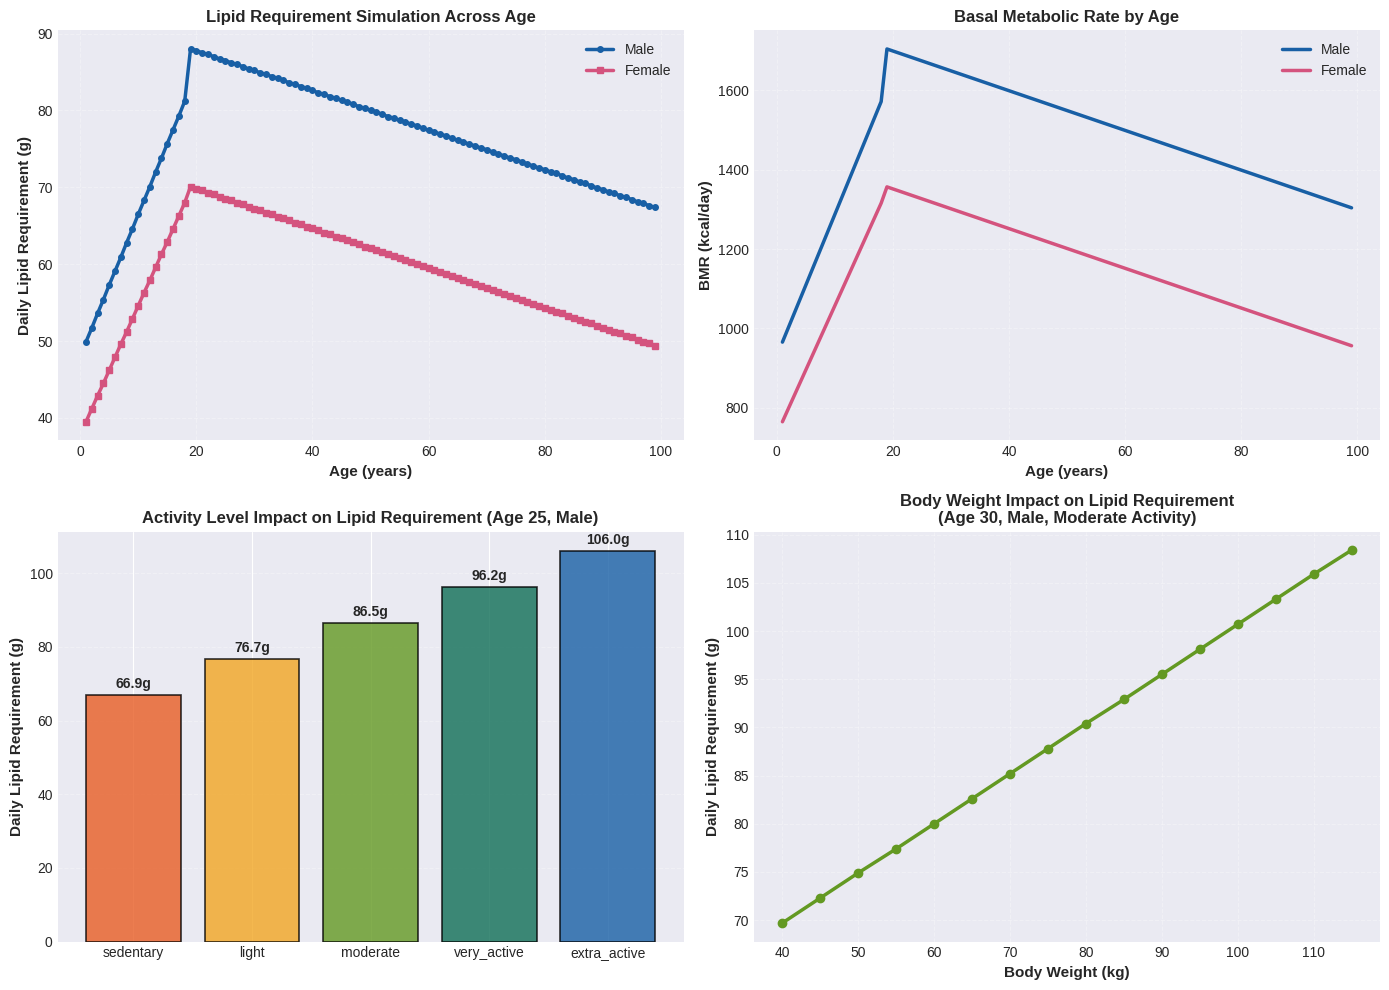

In [ ]:
# Generate visualization data across age range
ages = np.arange(1, 100, 1)
weights_by_age = {
    'Male': np.where(ages <= 18, 5 + ages*2.5, 70),
    'Female': np.where(ages <= 18, 5 + ages*2.3, 60)
}

lipid_by_age = {
    'Male': [simulate_lipid_metabolism(age, 'Male', weights_by_age['Male'][i], 'moderate')['daily_lipid_g']
             for i, age in enumerate(ages)],
    'Female': [simulate_lipid_metabolism(age, 'Female', weights_by_age['Female'][i], 'moderate')['daily_lipid_g']
               for i, age in enumerate(ages)]
}

# Main plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Lipid requirement per age (gender comparison)
ax = axes[0, 0]
ax.plot(ages, lipid_by_age['Male'], marker='o', linewidth=2.5, markersize=4,
        label='Male', color='#185FA5')
ax.plot(ages, lipid_by_age['Female'], marker='s', linewidth=2.5, markersize=4,
        label='Female', color='#D4537E')
ax.set_xlabel('Age (years)', fontsize=11, fontweight='bold')
ax.set_ylabel('Daily Lipid Requirement (g)', fontsize=11, fontweight='bold')
ax.set_title('Lipid Requirement Simulation Across Age', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)

# Plot 2: BMR vs Age
ax = axes[0, 1]
bmr_male = [calculate_bmr(age, 'Male', weights_by_age['Male'][i]) for i, age in enumerate(ages)]
bmr_female = [calculate_bmr(age, 'Female', weights_by_age['Female'][i]) for i, age in enumerate(ages)]
ax.plot(ages, bmr_male, linewidth=2.5, label='Male', color='#185FA5')
ax.plot(ages, bmr_female, linewidth=2.5, label='Female', color='#D4537E')
ax.set_xlabel('Age (years)', fontsize=11, fontweight='bold')
ax.set_ylabel('BMR (kcal/day)', fontsize=11, fontweight='bold')
ax.set_title('Basal Metabolic Rate by Age', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10)

# Plot 3: Activity level impact (age 25, male)
ax = axes[1, 0]
activities = ['sedentary', 'light', 'moderate', 'very_active', 'extra_active']
lipid_by_activity = [simulate_lipid_metabolism(25, 'Male', 70, act)['daily_lipid_g'] for act in activities]
colors_activity = ['#E85D24', '#F2A623', '#639922', '#0F6E56', '#185FA5']
ax.bar(activities, lipid_by_activity, color=colors_activity, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.set_ylabel('Daily Lipid Requirement (g)', fontsize=11, fontweight='bold')
ax.set_title('Activity Level Impact on Lipid Requirement (Age 25, Male)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
for i, v in enumerate(lipid_by_activity):
    ax.text(i, v + 1, f'{v:.1f}g', ha='center', va='bottom', fontweight='bold')

# Plot 4: Body weight impact (age 30, male, moderate activity)
ax = axes[1, 1]
weights = np.arange(40, 120, 5)
lipid_by_weight = [simulate_lipid_metabolism(30, 'Male', w, 'moderate')['daily_lipid_g'] for w in weights]
ax.plot(weights, lipid_by_weight, marker='o', linewidth=2.5, markersize=6, color='#639922')
ax.set_xlabel('Body Weight (kg)', fontsize=11, fontweight='bold')
ax.set_ylabel('Daily Lipid Requirement (g)', fontsize=11, fontweight='bold')
ax.set_title('Body Weight Impact on Lipid Requirement\n(Age 30, Male, Moderate Activity)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('lipid_simulation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Test 1: Age progression (constant weight & activity)
print("\n1️⃣ AGE PROGRESSION TEST (Body weight: 65kg, Activity: Moderate)")
print("-"*70)
test_ages = [1, 5, 12, 18, 25, 40, 60, 80]
for age in test_ages:
    result = simulate_lipid_metabolism(age, 'Male', 65, 'moderate')
    if result['status'] == 'success':
        print(f"Age {age:2d}: BMR={result['bmr']:7.1f} kcal | "
              f"TDEE={result['tdee']:7.1f} kcal | "
              f"Lipid={result['daily_lipid_g']:5.1f}g | {result['age_group']}")

# Test 2: Gender comparison
print("\n2️⃣ GENDER COMPARISON TEST (Age: 25, Body weight: 65kg, Activity: Moderate)")
print("-"*70)
for gender in ['Male', 'Female']:
    result = simulate_lipid_metabolism(25, gender, 65, 'moderate')
    if result['status'] == 'success':
        print(f"{gender:6s}: BMR={result['bmr']:7.1f} kcal | "
              f"TDEE={result['tdee']:7.1f} kcal | "
              f"Lipid={result['daily_lipid_g']:5.1f}g")

# Test 3: Activity level sensitivity
print("\n3️⃣ ACTIVITY LEVEL SENSITIVITY (Age: 30, Male, Body weight: 70kg)")
print("-"*70)
activities = ['sedentary', 'light', 'moderate', 'very_active', 'extra_active']
for activity in activities:
    result = simulate_lipid_metabolism(30, 'Male', 70, activity)
    if result['status'] == 'success':
        print(f"{activity:12s}: TDEE={result['tdee']:7.1f} kcal | "
              f"Lipid={result['daily_lipid_g']:5.1f}g")

# Test 4: Body weight impact
print("\n4️⃣ BODY WEIGHT IMPACT (Age: 25, Male, Activity: Moderate)")
print("-"*70)
weights = [50, 60, 70, 80, 90]
for weight in weights:
    result = simulate_lipid_metabolism(25, 'Male', weight, 'moderate')
    if result['status'] == 'success':
        print(f"Weight {weight}kg: BMR={result['bmr']:7.1f} kcal | "
              f"Lipid={result['daily_lipid_g']:5.1f}g")


1️⃣ AGE PROGRESSION TEST (Body weight: 65kg, Activity: Moderate)
----------------------------------------------------------------------
Age  1: BMR= 1540.6 kcal | TDEE= 2388.0 kcal | Lipid= 79.6g | Bayi (0-2)
Age  5: BMR= 1583.1 kcal | TDEE= 2453.8 kcal | Lipid= 81.8g | Anak (3-5)
Age 12: BMR= 1657.5 kcal | TDEE= 2569.1 kcal | Lipid= 85.6g | Anak (6-12)
Age 18: BMR= 1721.2 kcal | TDEE= 2667.9 kcal | Lipid= 88.9g | Remaja (13-18)
Age 25: BMR= 1623.8 kcal | TDEE= 2516.8 kcal | Lipid= 83.9g | Dewasa (19-50)
Age 40: BMR= 1548.8 kcal | TDEE= 2400.6 kcal | Lipid= 80.0g | Dewasa (19-50)
Age 60: BMR= 1448.8 kcal | TDEE= 2245.6 kcal | Lipid= 74.9g | Lansia (51+)
Age 80: BMR= 1348.8 kcal | TDEE= 2090.6 kcal | Lipid= 69.7g | Lansia (51+)

2️⃣ GENDER COMPARISON TEST (Age: 25, Body weight: 65kg, Activity: Moderate)
----------------------------------------------------------------------
Male  : BMR= 1623.8 kcal | TDEE= 2516.8 kcal | Lipid= 83.9g
Female: BMR= 1376.5 kcal | TDEE= 2133.6 kcal | Lipid= 

##Protein Module

In [ ]:
# PROTEIN MODULE — NutriAge

# BAGIAN 1: PERSIAPAN DATA PROTEIN

# Filter dan normalisasi data protein dari df hasil preprocessing
protein_df = df[['min_age', 'max_age', 'gender', 'protein_g']].copy()

# Normalisasi nilai gender agar konsisten (All → representasi umum)
protein_df['gender'] = protein_df['gender'].str.strip().str.lower()

# Buat representasi "All" gender → duplikasi sebagai Male & Female bila diperlukan
protein_all = protein_df[protein_df['gender'] == 'all'].copy()
protein_gendered = protein_df[protein_df['gender'].isin(['male', 'female'])].copy()

print("📊 DATA PROTEIN — Preview")
print("="*60)
print(f"Total baris data protein: {len(protein_df)}")
print(f"  → Dengan gender spesifik : {len(protein_gendered)}")
print(f"  → Dengan gender 'All'    : {len(protein_all)}")
print()
print(protein_df.sort_values(['min_age', 'gender']).to_string(index=False))

# BAGIAN 2: FUNGSI UTILITAS — KLASIFIKASI KELOMPOK USIA

def get_protein_age_group(age: float) -> dict:
    """
    Klasifikasikan usia ke dalam kelompok umur standar nutrisi.

    Parameter:
        age (float): Usia dalam tahun (0–120)

    Return:
        dict: label kelompok usia, fase biologis, dan fase metabolisme protein
    """
    if age < 0 or age > 120:
        return {'status': 'error', 'message': f'Usia tidak valid: {age}'}

    if age < 0.5:
        group, phase, meta_phase = "Bayi (0–6 bulan)", "Neonatal", "Pertumbuhan Pesat"
    elif age < 1:
        group, phase, meta_phase = "Bayi (6–12 bulan)", "Bayi Lanjut", "Pertumbuhan Pesat"
    elif age < 3:
        group, phase, meta_phase = "Bayi (1–2 tahun)", "Toddler", "Pertumbuhan Aktif"
    elif age < 6:
        group, phase, meta_phase = "Anak (3–5 tahun)", "Prasekolah", "Pertumbuhan Aktif"
    elif age < 10:
        group, phase, meta_phase = "Anak (6–9 tahun)", "Sekolah Dasar", "Pertumbuhan Stabil"
    elif age < 13:
        group, phase, meta_phase = "Anak (10–12 tahun)", "Prapubertas", "Persiapan Pubertas"
    elif age < 16:
        group, phase, meta_phase = "Remaja (13–15 tahun)", "Pubertas Awal", "Lonjakan Pertumbuhan"
    elif age < 19:
        group, phase, meta_phase = "Remaja (16–18 tahun)", "Pubertas Akhir", "Puncak Massa Otot"
    elif age < 30:
        group, phase, meta_phase = "Dewasa Muda (19–29 tahun)", "Dewasa Muda", "Pemeliharaan & Sintesis"
    elif age < 50:
        group, phase, meta_phase = "Dewasa (30–49 tahun)", "Dewasa Tengah", "Pemeliharaan"
    elif age < 65:
        group, phase, meta_phase = "Pralansia (50–64 tahun)", "Pra-Lansia", "Pemeliharaan Massa Otot"
    else:
        group, phase, meta_phase = "Lansia (65+ tahun)", "Lansia", "Pencegahan Sarkopenia"

    return {
        'status': 'ok',
        'age_group': group,
        'biological_phase': phase,
        'metabolic_phase': meta_phase
    }


# BAGIAN 3: FUNGSI LOOKUP — KEBUTUHAN PROTEIN DARI DATASET

def lookup_protein_from_dataset(age: float, gender: str) -> float | None:
    """
    Cari kebutuhan protein (gram/hari) dari dataset berdasarkan usia dan gender.

    Strategi pencarian:
        1. Cari baris dengan gender spesifik (male/female) yang mencakup usia tsb
        2. Bila tidak ada, fallback ke baris gender 'all'
        3. Bila tetap tidak ditemukan, kembalikan None (akan di-handle oleh simulasi)

    Parameter:
        age    (float): Usia dalam tahun
        gender (str)  : 'male' atau 'female'

    Return:
        float | None: Nilai protein dalam gram/hari, atau None bila tidak ditemukan
    """
    gender_norm = gender.strip().lower()

    # Cari baris yang rentang usianya mencakup age, dengan gender spesifik
    match = protein_gendered[
        (protein_gendered['gender'] == gender_norm) &
        (protein_gendered['min_age'] <= age) &
        (protein_gendered['max_age'] >= age)
    ]

    if not match.empty:
        return match['protein_g'].mean()  # Rata-rata bila ada >1 baris (duplikat)

    # Fallback: cari dari baris 'all' gender
    match_all = protein_all[
        (protein_all['min_age'] <= age) &
        (protein_all['max_age'] >= age)
    ]

    if not match_all.empty:
        return match_all['protein_g'].mean()

    return None  # Tidak ditemukan


# BAGIAN 4: FUNGSI UTAMA — SIMULASI KEBUTUHAN PROTEIN

def simulate_protein_requirement(age: float, gender: str) -> dict:
    """
    Simulasikan kebutuhan protein harian berdasarkan usia dan jenis kelamin.

    Pendekatan:
        - Lookup nilai referensi dari dataset (protein_df)
        - Bila data tidak tersedia, gunakan formula estimasi berbasis fase usia
        - Tambahkan konteks biologis dan rekomendasi tekstual

    Parameter:
        age    (float): Usia dalam tahun (0–120)
        gender (str)  : 'Male' atau 'Female'

    Return:
        dict: Hasil simulasi lengkap (protein_g, kelompok usia, rekomendasi, dsb.)
    """

    if age < 0 or age > 120:
        return {'status': 'error', 'message': f'Usia tidak valid: {age}. Masukkan nilai 0–120.'}

    if gender.strip().lower() not in ['male', 'female']:
        return {'status': 'error', 'message': f'Gender tidak valid: {gender}. Gunakan "Male" atau "Female".'}

    age_info = get_protein_age_group(age)
    if age_info['status'] == 'error':
        return age_info

    protein_g = lookup_protein_from_dataset(age, gender)

    if protein_g is None:
        bw_estimate = estimate_body_weight(age, gender)
        protein_g = bw_estimate * 0.8
        data_source = 'estimated (0.8 g/kg × berat badan ideal)'
    else:
        data_source = 'dataset referensi'

    bw = estimate_body_weight(age, gender)
    protein_per_kg = round(protein_g / bw, 2) if bw > 0 else None

    recommendation = generate_protein_recommendation(age_info, gender, protein_g)

    bio_insight = get_biological_insight(age_info['metabolic_phase'])

    return {
        'status'          : 'success',
        'age'             : age,
        'gender'          : gender.capitalize(),
        'age_group'       : age_info['age_group'],
        'biological_phase': age_info['biological_phase'],
        'metabolic_phase' : age_info['metabolic_phase'],
        'protein_g_per_day': round(protein_g, 1),
        'protein_per_kg'  : protein_per_kg,
        'body_weight_est' : round(bw, 1),
        'data_source'     : data_source,
        'recommendation'  : recommendation,
        'bio_insight'     : bio_insight
    }


def estimate_body_weight(age: float, gender: str) -> float:
    """
    Estimasi berat badan ideal berdasarkan usia dan gender.
    Menggunakan kurva pertumbuhan WHO yang disederhanakan.
    """
    gender_lower = gender.strip().lower()

    if age < 1:
        return 3.5 + age * 6
    elif age < 10:
        return 8 + age * 2.5
    elif age < 18:
        if gender_lower == 'male':
            return 30 + (age - 10) * 4.5
        else:
            return 28 + (age - 10) * 3.8
    else:
        if gender_lower == 'male':
            return 70.0
        else:
            return 58.0


def generate_protein_recommendation(age_info: dict, gender: str, protein_g: float) -> str:
    """Hasilkan teks rekomendasi konsumsi protein berdasarkan fase metabolisme."""
    phase = age_info['metabolic_phase']
    group = age_info['age_group']
    gender_cap = gender.capitalize()

    recs = {
        'Pertumbuhan Pesat'   : (f"{group} membutuhkan {protein_g:.1f}g protein/hari untuk mendukung "
                                  "pertumbuhan sel, organ, dan otak yang sangat cepat. "
                                  "Utamakan ASI atau susu formula yang kaya protein berkualitas tinggi."),
        'Pertumbuhan Aktif'   : (f"{gender_cap} usia {group} memerlukan {protein_g:.1f}g protein/hari. "
                                  "Penuhi dari sumber hewani (telur, ikan, daging) dan nabati (tahu, tempe) "
                                  "untuk mendukung perkembangan otot dan tulang."),
        'Pertumbuhan Stabil'  : (f"Kebutuhan protein {protein_g:.1f}g/hari mendukung pertumbuhan "
                                  "yang lebih stabil. Variasi sumber protein penting untuk asupan asam amino esensial lengkap."),
        'Persiapan Pubertas'  : (f"Menjelang pubertas, kebutuhan protein meningkat menjadi {protein_g:.1f}g/hari. "
                                  "Pastikan asupan protein cukup untuk mempersiapkan lonjakan pertumbuhan."),
        'Lonjakan Pertumbuhan': (f"Fase pubertas membutuhkan {protein_g:.1f}g protein/hari — salah satu kebutuhan "
                                  "tertinggi dalam hidup. Protein sangat dibutuhkan untuk pembentukan massa otot dan tulang."),
        'Puncak Massa Otot'   : (f"Usia ini adalah puncak pembentukan massa otot. Asupan {protein_g:.1f}g/hari "
                                  "sangat penting untuk mencapai dan mempertahankan massa otot maksimal."),
        'Pemeliharaan & Sintesis': (f"Dewasa muda membutuhkan {protein_g:.1f}g protein/hari untuk sintesis enzim, "
                                     "hormon, dan pemeliharaan jaringan. Distribusikan asupan protein merata sepanjang hari."),
        'Pemeliharaan'        : (f"Kebutuhan protein stabil di {protein_g:.1f}g/hari untuk pemeliharaan jaringan tubuh. "
                                  "Batasi protein berlebih untuk menjaga fungsi ginjal."),
        'Pemeliharaan Massa Otot': (f"Mulai terjadi penurunan massa otot alami (sarkopenia). "
                                     f"Pertahankan asupan {protein_g:.1f}g/hari dan kombinasikan dengan aktivitas fisik ringan."),
        'Pencegahan Sarkopenia': (f"Lansia rentan kehilangan massa otot. Asupan {protein_g:.1f}g protein/hari "
                                   "dengan sumber berkualitas tinggi (telur, ikan) penting untuk mencegah sarkopenia dan frailty.")
    }
    return recs.get(phase, f"Konsumsi {protein_g:.1f}g protein per hari sesuai rekomendasi untuk {group}.")


def get_biological_insight(metabolic_phase: str) -> str:
    """Kembalikan insight biologis singkat berdasarkan fase metabolisme protein."""
    insights = {
        'Pertumbuhan Pesat'   : "Sintesis protein sangat tinggi; asam amino esensial seperti leusin kritis untuk mielinasi saraf.",
        'Pertumbuhan Aktif'   : "Turnover protein tinggi mendukung pertumbuhan otot rangka dan kolagen tulang.",
        'Pertumbuhan Stabil'  : "Sintesis protein mulai terregulasi; keseimbangan nitrogen positif diperlukan.",
        'Persiapan Pubertas'  : "Hormon pertumbuhan (GH) meningkat; protein dibutuhkan sebagai substrat IGF-1.",
        'Lonjakan Pertumbuhan': "Testosteron/estrogen memacu sintesis protein otot (anabolisme); kebutuhan nitrogen melonjak.",
        'Puncak Massa Otot'   : "Massa otot mencapai puncak; protein diperlukan untuk konsolidasi serabut otot tipe II.",
        'Pemeliharaan & Sintesis': "Turnover protein ~300g/hari pada orang dewasa; ~70–100g harus dipasok dari makanan.",
        'Pemeliharaan'        : "Keseimbangan nitrogen mendekati nol; kelebihan protein dideaminasi di hati menjadi urea.",
        'Pemeliharaan Massa Otot': "Resistensi anabolik mulai muncul; dibutuhkan lebih banyak leusin untuk memicu sintesis protein otot.",
        'Pencegahan Sarkopenia': "Sarkopenia terjadi akibat penurunan sintesis protein miofibrilar; asupan protein ≥1.2 g/kg/hari direkomendasikan."
    }
    return insights.get(metabolic_phase, "Protein berperan dalam hampir semua proses biologis tubuh.")


# BAGIAN 6: PENGUJIAN FUNGSI SIMULASI

print("\nPROTEIN MODULE — Simulation Testing")
print("="*70)

test_cases = [
    (0.3,  'Male'),
    (1,    'Female'),
    (5,    'Male'),
    (12,   'Female'),
    (16,   'Male'),
    (25,   'Female'),
    (40,   'Male'),
    (60,   'Female'),
    (75,   'Male'),
]

protein_results = []

for age, gender in test_cases:
    result = simulate_protein_requirement(age, gender)
    protein_results.append(result)
    if result['status'] == 'success':
        print(f"Usia {str(age):5s} | {gender:6s} | "
              f"BB ~{result['body_weight_est']:5.1f}kg | "
              f"Protein: {result['protein_g_per_day']:5.1f} g/hari | "
              f"{result['protein_per_kg']} g/kg")
        print(f"  Kelompok : {result['age_group']}")
        print(f"  Fase     : {result['metabolic_phase']}")
        print(f"  Sumber   : {result['data_source']}")
        print()


📊 DATA PROTEIN — Preview
Total baris data protein: 95
  → Dengan gender spesifik : 78
  → Dengan gender 'All'    : 17

 min_age  max_age gender  protein_g
     0.0      0.5    all        9.1
     0.0      0.5    all        9.1
     0.0      0.5    all        9.1
     0.5      1.0    all       11.0
     0.5      1.0    all       11.0
     0.5      1.0    all       11.0
     1.0      2.0    all       11.0
     1.0      2.0    all       11.0
     1.0      2.0    all       10.8
     1.0      2.0   male       11.0
     2.0      3.0    all       14.0
     2.0      3.0    all       14.0
     2.0      3.0 female       14.2
     2.0      3.0 female       14.5
     3.0      5.0    all       19.0
     3.0      5.0    all       19.0
     3.0      5.0   male       19.5
     3.0      5.0   male       19.2
     6.0      8.0    all       25.0
     6.0      8.0    all       25.0
     6.0      8.0 female       24.8
     6.0      8.0 female       25.0
     6.0      8.0   male       26.0
     9.0     11.0

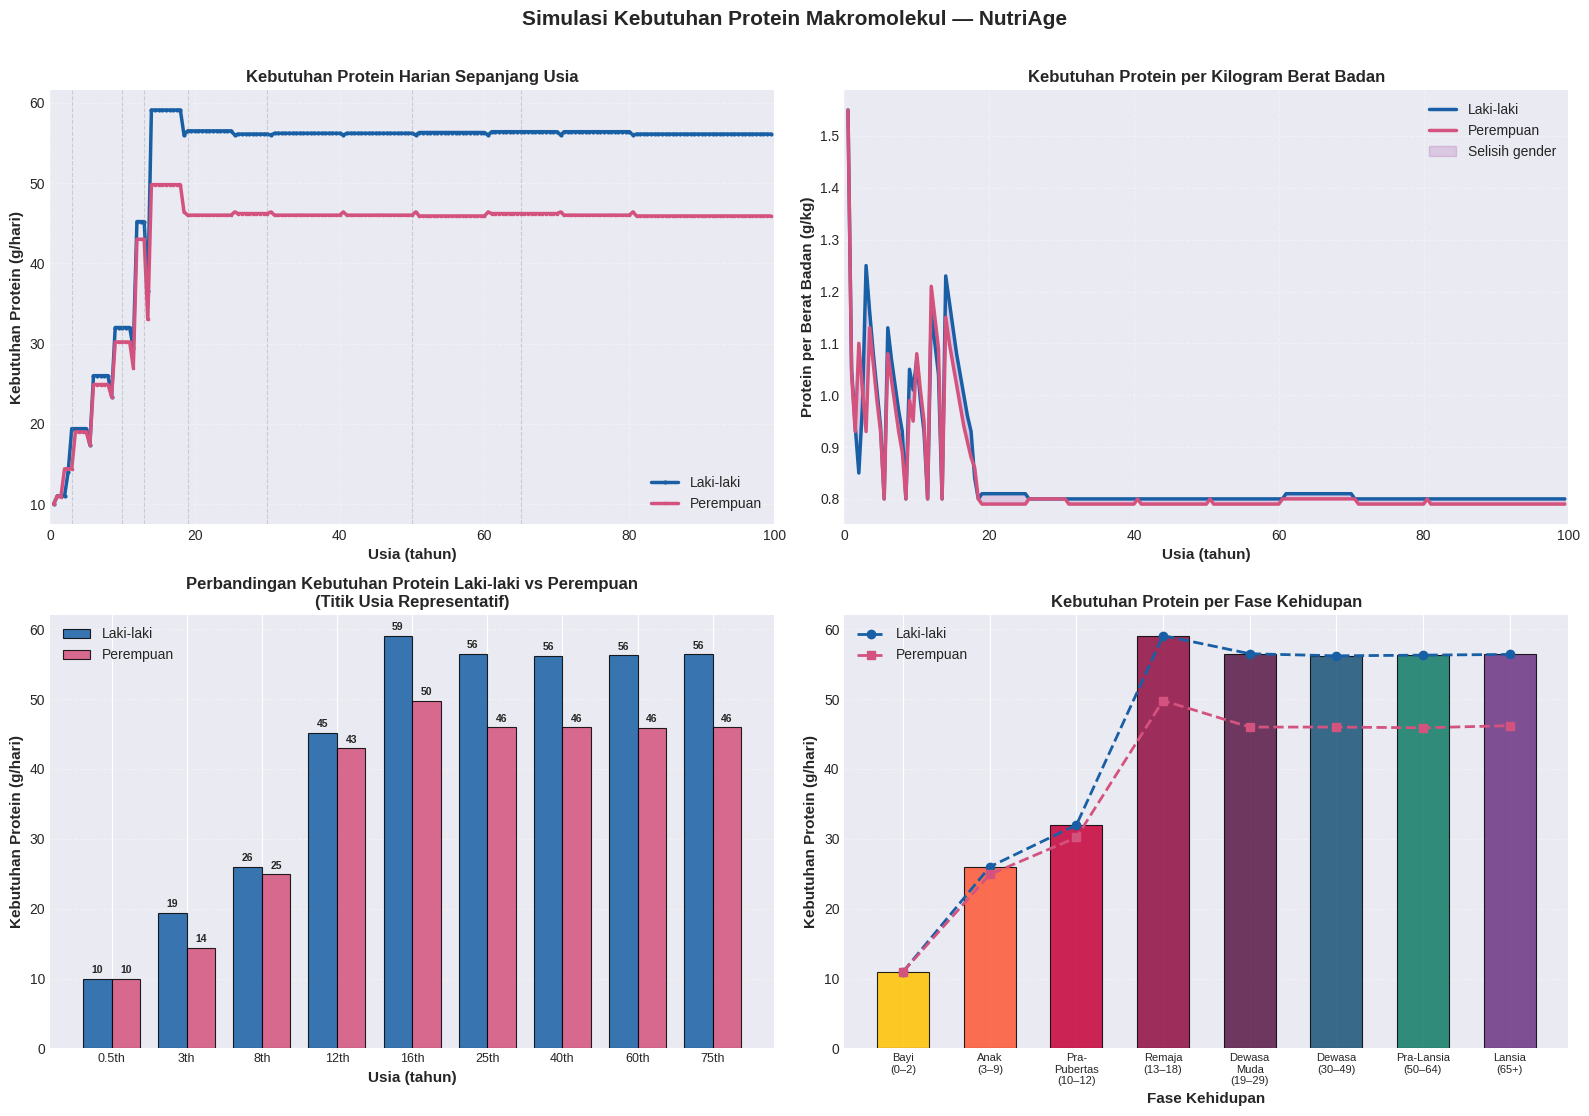

Grafik disimpan sebagai protein_simulation_analysis.png


In [ ]:
# BAGIAN 7: VISUALISASI KEBUTUHAN PROTEIN SEPANJANG USIA

ages_viz = np.arange(0.5, 100, 0.5)

# Hitung kebutuhan protein untuk setiap titik usia
protein_male_viz   = [simulate_protein_requirement(a, 'Male')['protein_g_per_day']   for a in ages_viz]
protein_female_viz = [simulate_protein_requirement(a, 'Female')['protein_g_per_day'] for a in ages_viz]
protein_per_kg_male_viz   = [simulate_protein_requirement(a, 'Male')['protein_per_kg']   for a in ages_viz]
protein_per_kg_female_viz = [simulate_protein_requirement(a, 'Female')['protein_per_kg'] for a in ages_viz]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Simulasi Kebutuhan Protein Makromolekul — NutriAge',
             fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Kebutuhan protein (g/hari) vs Usia
ax = axes[0, 0]
ax.plot(ages_viz, protein_male_viz,   linewidth=2.5, label='Laki-laki', color='#185FA5', marker='o', markersize=2)
ax.plot(ages_viz, protein_female_viz, linewidth=2.5, label='Perempuan',  color='#D4537E', marker='s', markersize=2)
for x_line in [3, 10, 13, 19, 30, 50, 65]:
    ax.axvline(x=x_line, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
ax.set_xlabel('Usia (tahun)', fontsize=11, fontweight='bold')
ax.set_ylabel('Kebutuhan Protein (g/hari)', fontsize=11, fontweight='bold')
ax.set_title('Kebutuhan Protein Harian Sepanjang Usia', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0, 100)

# Plot 2: Protein per kg berat badan vs Usia
ax = axes[0, 1]
ax.plot(ages_viz, protein_per_kg_male_viz,   linewidth=2.5, label='Laki-laki', color='#185FA5')
ax.plot(ages_viz, protein_per_kg_female_viz, linewidth=2.5, label='Perempuan',  color='#D4537E')
ax.fill_between(ages_viz, protein_per_kg_male_viz, protein_per_kg_female_viz,
                alpha=0.15, color='purple', label='Selisih gender')
ax.set_xlabel('Usia (tahun)', fontsize=11, fontweight='bold')
ax.set_ylabel('Protein per Berat Badan (g/kg)', fontsize=11, fontweight='bold')
ax.set_title('Kebutuhan Protein per Kilogram Berat Badan', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0, 100)

# Plot 3: Perbandingan gender pada usia representatif (grouped bar)
ax = axes[1, 0]
rep_ages   = [0.5, 3, 8, 12, 16, 25, 40, 60, 75]
rep_labels = ['0.5', '3', '8', '12', '16', '25', '40', '60', '75']
rep_male   = [simulate_protein_requirement(a, 'Male')['protein_g_per_day']   for a in rep_ages]
rep_female = [simulate_protein_requirement(a, 'Female')['protein_g_per_day'] for a in rep_ages]
x_pos = np.arange(len(rep_ages))
bar_w = 0.38
bars_m = ax.bar(x_pos - bar_w/2, rep_male,   bar_w, label='Laki-laki',
                color='#185FA5', alpha=0.85, edgecolor='black', linewidth=0.8)
bars_f = ax.bar(x_pos + bar_w/2, rep_female, bar_w, label='Perempuan',
                color='#D4537E', alpha=0.85, edgecolor='black', linewidth=0.8)
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{a}th' for a in rep_labels], fontsize=9)
ax.set_xlabel('Usia (tahun)', fontsize=11, fontweight='bold')
ax.set_ylabel('Kebutuhan Protein (g/hari)', fontsize=11, fontweight='bold')
ax.set_title('Perbandingan Kebutuhan Protein Laki-laki vs Perempuan\n(Titik Usia Representatif)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 4: Protein per fase kehidupan
ax = axes[1, 1]
phase_labels = ['Bayi\n(0–2)', 'Anak\n(3–9)', 'Pra-\nPubertas\n(10–12)',
                'Remaja\n(13–18)', 'Dewasa\nMuda\n(19–29)', 'Dewasa\n(30–49)',
                'Pra-Lansia\n(50–64)', 'Lansia\n(65+)']
phase_rep_ages   = [1, 6, 11, 16, 25, 40, 57, 70]
phase_male_vals   = [simulate_protein_requirement(a, 'Male')['protein_g_per_day']   for a in phase_rep_ages]
phase_female_vals = [simulate_protein_requirement(a, 'Female')['protein_g_per_day'] for a in phase_rep_ages]
x_ph = np.arange(len(phase_labels))
colors_phase = ['#FFC300', '#FF5733', '#C70039', '#900C3F', '#571845', '#1A5276', '#117A65', '#6C3483']
ax.bar(x_ph, phase_male_vals, 0.6, color=colors_phase, alpha=0.85, edgecolor='black', linewidth=0.8)
ax.plot(x_ph, phase_male_vals,   'o--', color='#185FA5', linewidth=2, markersize=6, label='Laki-laki')
ax.plot(x_ph, phase_female_vals, 's--', color='#D4537E', linewidth=2, markersize=6, label='Perempuan')
ax.set_xticks(x_ph)
ax.set_xticklabels(phase_labels, fontsize=8)
ax.set_xlabel('Fase Kehidupan', fontsize=11, fontweight='bold')
ax.set_ylabel('Kebutuhan Protein (g/hari)', fontsize=11, fontweight='bold')
ax.set_title('Kebutuhan Protein per Fase Kehidupan', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('protein_simulation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafik disimpan sebagai protein_simulation_analysis.png')


#Integration & Combination

#Web Implementation

# Model Training for Streamlit App

Cell tambahan ini melatih model regresi multi-output dari dataset nutrisi dan menyimpan artifact yang dipakai aplikasi Streamlit. <!-- MODEL_TRAINING_FOR_STREAMLIT_APP -->


In [ ]:
# MODEL_TRAINING_FOR_STREAMLIT_APP
from pathlib import Path
from datetime import datetime
import json
import warnings

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, SplineTransformer

warnings.filterwarnings('ignore')

ROOT_DIR = Path.cwd().parent if Path.cwd().name.lower() == 'pipeline' else Path.cwd()
DATASET_PATH = ROOT_DIR / 'pipeline' / 'nutrient_dataset_raw (1).csv'
MODEL_DIR = ROOT_DIR / 'models'
MODEL_PATH = MODEL_DIR / 'nutriage_macro_model.joblib'
METADATA_PATH = MODEL_DIR / 'nutriage_macro_model_metadata.json'

FEATURE_COLUMNS = ['age', 'gender']
TARGET_COLUMNS = ['carbohydrate_g', 'protein_g', 'lipid_g']


def normalize_gender(value):
    gender = str(value).strip().lower()
    if gender in {'male', 'm', 'laki-laki', 'laki laki'}:
        return 'Male'
    if gender in {'female', 'f', 'perempuan'}:
        return 'Female'
    if gender == 'all':
        return 'All'
    return np.nan


def load_and_clean_dataset(path):
    raw = pd.read_csv(path)
    data = raw.copy()
    data.columns = data.columns.str.strip().str.lower()

    required_columns = ['min_age', 'max_age', 'gender', *TARGET_COLUMNS]
    missing_columns = [col for col in required_columns if col not in data.columns]
    if missing_columns:
        raise KeyError(f'Kolom dataset tidak lengkap: {missing_columns}')

    data = data[required_columns].copy()
    data['gender'] = data['gender'].apply(normalize_gender)
    for col in ['min_age', 'max_age', *TARGET_COLUMNS]:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    data = data.dropna(subset=['min_age', 'max_age', 'gender'])
    data = data[(data['min_age'] <= data['max_age']) & (data['min_age'] >= 0) & (data['max_age'] <= 120)]

    valid_ranges = {
        'carbohydrate_g': (20, 500),
        'protein_g': (5, 140),
        'lipid_g': (10, 140),
    }
    for col, (lower, upper) in valid_ranges.items():
        data.loc[(data[col] < lower) | (data[col] > upper), col] = np.nan

    data = data.dropna(subset=TARGET_COLUMNS)
    data = data.drop_duplicates()

    expanded_gender_rows = []
    for _, row in data.iterrows():
        genders = ['Male', 'Female'] if row['gender'] == 'All' else [row['gender']]
        for gender in genders:
            expanded_row = row.copy()
            expanded_row['gender'] = gender
            expanded_gender_rows.append(expanded_row)

    return pd.DataFrame(expanded_gender_rows).reset_index(drop=True)


def expand_age_ranges(data):
    rows = []
    for _, row in data.iterrows():
        start_age = max(1, int(np.ceil(row['min_age'])))
        end_age = min(100, int(np.floor(row['max_age'])))
        if start_age > end_age:
            continue

        for age in range(start_age, end_age + 1):
            rows.append({
                'age': age,
                'gender': row['gender'],
                'carbohydrate_g': float(row['carbohydrate_g']),
                'protein_g': float(row['protein_g']),
                'lipid_g': float(row['lipid_g']),
            })

    expanded = pd.DataFrame(rows)
    expanded = expanded.groupby(FEATURE_COLUMNS, as_index=False)[TARGET_COLUMNS].mean()
    return expanded.sort_values(FEATURE_COLUMNS).reset_index(drop=True)


clean_df = load_and_clean_dataset(DATASET_PATH)
training_df = expand_age_ranges(clean_df)

X = training_df[FEATURE_COLUMNS]
y = training_df[TARGET_COLUMNS]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=X['gender'],
)

preprocessor = ColumnTransformer(
    transformers=[
        ('age_spline', SplineTransformer(
            n_knots=28,
            degree=3,
            include_bias=False,
            extrapolation='continue',
        ), ['age']),
        ('gender', OneHotEncoder(handle_unknown='ignore'), ['gender']),
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('interactions', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('regressor', Ridge(alpha=0.05)),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics = {}
for index, target in enumerate(TARGET_COLUMNS):
    metrics[target] = {
        'mae': round(float(mean_absolute_error(y_test[target], y_pred[:, index])), 3),
        'rmse': round(float(np.sqrt(mean_squared_error(y_test[target], y_pred[:, index]))), 3),
        'r2': round(float(r2_score(y_test[target], y_pred[:, index])), 3),
    }

MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)

metadata = {
    'created_at': datetime.now().isoformat(timespec='seconds'),
    'dataset_path': str(DATASET_PATH.relative_to(ROOT_DIR)),
    'model_path': str(MODEL_PATH.relative_to(ROOT_DIR)),
    'feature_columns': FEATURE_COLUMNS,
    'target_columns': TARGET_COLUMNS,
    'raw_rows': int(pd.read_csv(DATASET_PATH).shape[0]),
    'clean_rows': int(clean_df.shape[0]),
    'training_rows': int(training_df.shape[0]),
    'train_rows': int(X_train.shape[0]),
    'test_rows': int(X_test.shape[0]),
    'model': 'SplineTransformer + Polynomial interaction features + Ridge regression',
    'smoothing_strategy': {
        'age_basis': 'cubic B-spline',
        'n_knots': 28,
        'ridge_alpha': 0.05,
        'gender_strategy': 'one-hot gender with spline interaction features',
    },
    'metrics': metrics,
}

with METADATA_PATH.open('w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('Training selesai dengan smooth spline model.')
print(f'Model disimpan ke: {MODEL_PATH}')
print(f'Metadata disimpan ke: {METADATA_PATH}')
print(json.dumps(metadata, indent=2, ensure_ascii=False))
